# 1 Data exploring and preprocessing

In [17]:
"""
Data Exploration: Mobile Device Usage and User Behavior

Dataset:
Khorasani, V. (2024). Mobile Device Usage and User Behavior Dataset. 
Kaggle. https://doi.org/10.34740/KAGGLE/DV/4455

License: Apache 2.0
"""

'\nData Exploration: Mobile Device Usage and User Behavior\n\nDataset:\nKhorasani, V. (2024). Mobile Device Usage and User Behavior Dataset. \nKaggle. https://doi.org/10.34740/KAGGLE/DV/4455\n\nLicense: Apache 2.0\n'

In [18]:
### Import libraries

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

### Define project paths

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "01_data" / "01_user_behavior_dataset_original.csv"


### Helper function to load data from a CSV file into a pandas DataFrame

def load_data(file_path):
    """
    Load data from a CSV file into a pandas DataFrame.

    Parameters:
        file_path (str or Path): Path to the CSV file.

    Returns:
        pd.DataFrame or None: Loaded data, or None if loading fails.
    """
    try:
        return pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"Error: The file at '{file_path}' was not found.")
    except pd.errors.EmptyDataError:
        print(f"Error: The file at '{file_path}' is empty.")
    except pd.errors.ParserError:
        print(f"Error: The file at '{file_path}' could not be parsed.")

    return None


### Load data

df = load_data(DATA_PATH)

if df is None:
    raise FileNotFoundError(f"Could not load source data from: {DATA_PATH}")

### Data Audit

In [19]:
print(df.shape)
df.describe()

(700, 11)


,User ID,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,User Behavior Class
count,700.00000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,350.50000,271.128571,5.272714,1525.158571,50.681429,929.742857,38.482857,2.990000
std,202.21688,177.199484,3.068584,819.136414,26.943324,640.451729,12.012916,1.401476
min,1.00000,30.000000,1.000000,302.000000,10.000000,102.000000,18.000000,1.000000
25%,175.75000,113.250000,2.500000,722.250000,26.000000,373.000000,28.000000,2.000000
50%,350.50000,227.500000,4.900000,1502.500000,49.000000,823.500000,38.000000,3.000000
75%,525.25000,434.250000,7.400000,2229.500000,74.000000,1341.000000,49.000000,4.000000
max,700.00000,598.000000,12.000000,2993.000000,99.000000,2497.000000,59.000000,5.000000


In [20]:
df.isna().sum()

User ID                       0
Device Model                  0
Operating System              0
App Usage Time (min/day)      0
Screen On Time (hours/day)    0
Battery Drain (mAh/day)       0
Number of Apps Installed      0
Data Usage (MB/day)           0
Age                           0
Gender                        0
User Behavior Class           0
dtype: int64

### Data cleaning

In [21]:
# Cleaning the data
df['Age'] = df['Age'].astype(int) 


### Data preprocessing

In [22]:
# Additional columns for Power BI

# usage Intensity Classification based on App Usage Time (min/day)
df['Usage Intensity'] = pd.cut(
    df['App Usage Time (min/day)'],
    bins=[0, 60, 180, 360, float('inf')],
    labels=['Low (<1h)', 'Medium (1-3h)', 'High (3-6h)', 'Extreme (6h+)']
)

# Battery Drain Categories
df['Battery Category'] = pd.cut(
    df['Battery Drain (mAh/day)'],
    bins=[0, 2000, 3500, 5000, float('inf')],
    labels=['Low', 'Medium', 'High', 'Very High']
)

df['Gender_Encoded'] = df['Gender'].map({'Male': 0, 'Female': 1})

# App share calculation: App Usage Time (min/day) / Screen On Time (min/day)
df['Screen On Time (min/day)'] = df['Screen On Time (hours/day)'] * 60
df['Relative App Usage Index'] = df['App Usage Time (min/day)'] / df['Screen On Time (min/day)']

df['Relative App Usage Index'].describe()


count    700.000000
mean       0.824030
std        0.204378
min        0.263158
25%        0.690814
50%        0.828878
75%        0.965004
max        1.316667
Name: Relative App Usage Index, dtype: float64

In [23]:
above_100 = df.loc[
    df['Relative App Usage Index'] > 1,
    [
        'User ID',
        'App Usage Time (min/day)',
        'Screen On Time (hours/day)',
        'Screen On Time (min/day)',
        'Relative App Usage Index'
    ]
].sort_values('Relative App Usage Index', ascending=False)

above_100

,User ID,App Usage Time (min/day),Screen On Time (hours/day),Screen On Time (min/day),Relative App Usage Index
133,134,79,1.0,60.0,1.316667
302,303,469,6.0,360.0,1.302778
273,274,179,2.3,138.0,1.297101
377,378,458,6.0,360.0,1.272222
637,638,83,1.1,66.0,1.257576
...,...,...,...,...,...
183,184,73,1.2,72.0,1.013889
121,122,529,8.7,522.0,1.013410
301,302,267,4.4,264.0,1.011364
538,539,576,9.5,570.0,1.010526


### Data exploration

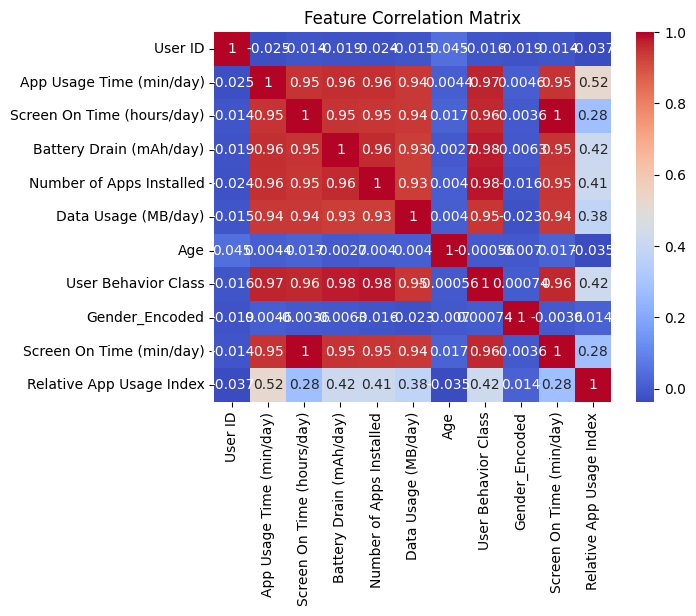

In [24]:
# Correlation matrix and heatmap

corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

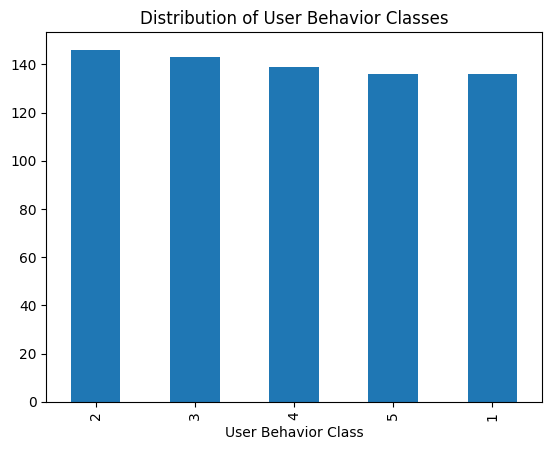

In [25]:
df['User Behavior Class'].value_counts().plot(kind='bar')
plt.title('Distribution of User Behavior Classes')
plt.show()

### Save Data

In [28]:
# Save cleaned data to a new CSV file

CLEANED_DATA_PATH = PROJECT_ROOT / "01_data" / "02_user_behavior_dataset_cleaned.csv"

CLEANED_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)

df.to_csv(CLEANED_DATA_PATH, index=False)

print(f"Cleaned data saved to: {CLEANED_DATA_PATH}")

Cleaned data saved to: c:\Users\heike\Documents\decoding-device-behavior\01_data\02_user_behavior_dataset_cleaned.csv
